# 02 — Feature Engineering

Calls `src/features.py` functions. No logic lives here.

In [6]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config
from src.features import compute_volatility_features

## Task 2.1 — Volatility Features

Five features per stock per week: RV at 5, 10, 21, 63 trading day lookbacks, plus RV(5d)/RV(63d) ratio.
Each value uses only daily returns strictly before the prediction week starts.

In [7]:
# Load data produced by Phase 1
log_returns = pd.read_parquet(f"{config.DATA_RAW_DIR}/log_returns.parquet")
weekly_rv   = pd.read_parquet(f"{config.DATA_RAW_DIR}/weekly_rv.parquet")

vol_features = compute_volatility_features(log_returns, weekly_rv)
print("Shape:", vol_features.shape)
print("Feature names:", vol_features.columns.get_level_values(0).unique().tolist())

Shape: (573, 250)
Feature names: ['rv_5d', 'rv_10d', 'rv_21d', 'rv_63d', 'rv_ratio']


In [8]:
# Spot-check 1: RV values must be positive (ignoring NaN warm-up rows)
for feat in ["rv_5d", "rv_10d", "rv_21d", "rv_63d"]:
    vals = vol_features[feat].values
    non_nan = vals[~np.isnan(vals)]
    assert (non_nan >= 0).all(), f"{feat} contains negative values"
    print(f"{feat}: min={non_nan.min():.4f}  mean={non_nan.mean():.4f}  max={non_nan.max():.4f}")

ratio_vals = vol_features["rv_ratio"].values
ratio_non_nan = ratio_vals[~np.isnan(ratio_vals)]
print(f"rv_ratio: min={ratio_non_nan.min():.4f}  mean={ratio_non_nan.mean():.4f}  max={ratio_non_nan.max():.4f}")

rv_5d: min=0.0102  mean=0.2389  max=5.6861
rv_10d: min=0.0275  mean=0.2523  max=4.3792
rv_21d: min=0.0607  mean=0.2619  max=3.5477
rv_63d: min=0.0806  mean=0.2721  max=2.3355
rv_ratio: min=0.0512  mean=0.8926  max=3.5778


In [9]:
# Spot-check 2: RV_5d should be more variable than RV_63d (short-term vol is noisier)
std_5d  = vol_features["rv_5d"].stack().std()
std_63d = vol_features["rv_63d"].stack().std()
print(f"Cross-stock/time std — rv_5d: {std_5d:.4f}   rv_63d: {std_63d:.4f}")
assert std_5d > std_63d, "Expected rv_5d to be more variable than rv_63d"

# Spot-check 3: rv_ratio should spike during the March 2020 COVID week
# The week of 2020-03-16 should have an above-average ratio (short-term vol >> long-term baseline)
covid_week = pd.Timestamp("2020-03-16")
if covid_week in vol_features.index:
    median_ratio  = vol_features["rv_ratio"].median(axis=1)
    overall_median = median_ratio.median()
    covid_ratio    = median_ratio.loc[covid_week]
    print(f"Median rv_ratio — overall: {overall_median:.3f}   2020-03-16: {covid_ratio:.3f}")
    assert covid_ratio > overall_median * 2, (
        f"Expected COVID ratio >> overall median; got {covid_ratio:.3f} vs {overall_median:.3f}"
    )
else:
    print("2020-03-16 not in index (may be a holiday-shortened week that was dropped)")

Cross-stock/time std — rv_5d: 0.1849   rv_63d: 0.1360
Median rv_ratio — overall: 0.797   2020-03-16: 2.949


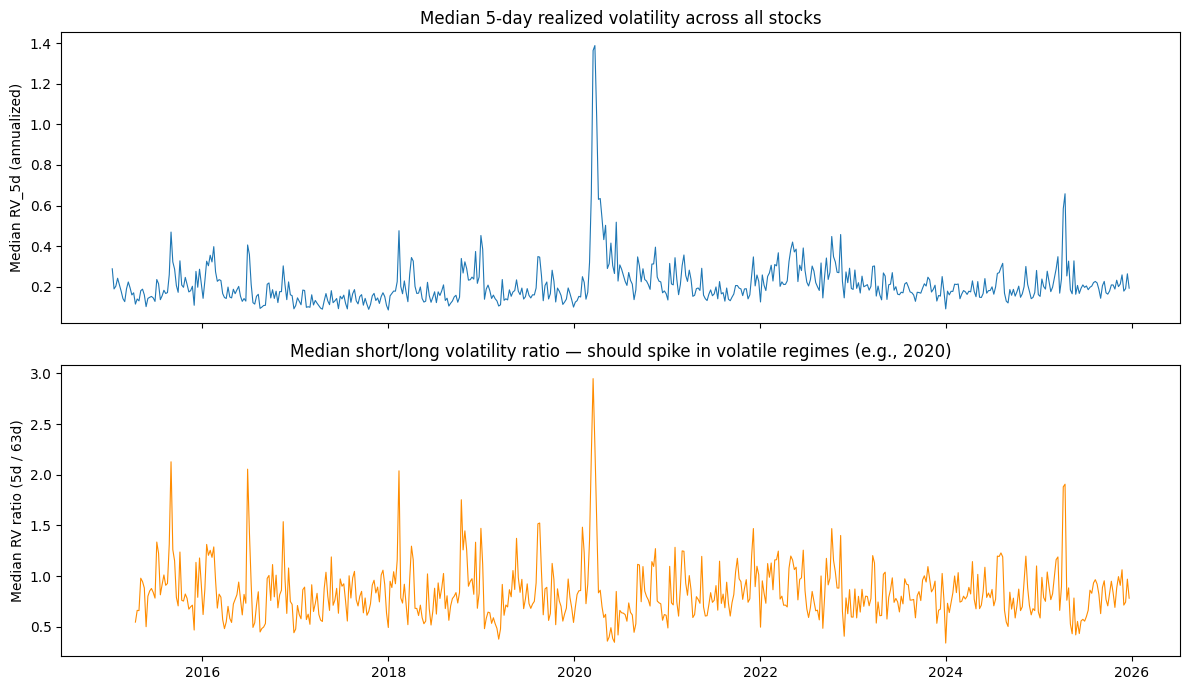

In [10]:
# Plot: median rv_5d and rv_ratio over time to visually confirm volatility clustering and COVID spike
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

median_rv5   = vol_features["rv_5d"].median(axis=1)
median_ratio = vol_features["rv_ratio"].median(axis=1)

axes[0].plot(median_rv5.index, median_rv5.values, linewidth=0.8)
axes[0].set_ylabel("Median RV_5d (annualized)")
axes[0].set_title("Median 5-day realized volatility across all stocks")

axes[1].plot(median_ratio.index, median_ratio.values, linewidth=0.8, color="darkorange")
axes[1].set_ylabel("Median RV ratio (5d / 63d)")
axes[1].set_title("Median short/long volatility ratio — should spike in volatile regimes (e.g., 2020)")

plt.tight_layout()
plt.show()